# Reproducing the Runs N' Poses similarity-performance analysis

This notebook reproduces the benchmark dataset used in the Runs N' Poses study starting from the original data released by the authors. The objective is to reconstruct the benchmark and training datasets, inspect the information provided for each protein–ligand complex, and reproduce the relationship between structural similarity and model performance reported in the original publication.

The notebook performs the following steps:

1. Download the original Runs N' Poses datasets from Zenodo.
2. Load and inspect the benchmark annotations and similarity files.
3. Reconstruct the benchmark and training system collections.
4. Reproduce the similarity-versus-success analysis reported in the paper.

All analyses in the subsequent notebooks are based on the datasets generated here.

### Required files

Before running this notebook, download the following files from the Runs N' Poses Zenodo repository and place them in the `Dataset/` directory (or modify the paths accordingly).

|            File            |          Description          |
|:-------------------------- | -----------------------------:|
|`annotations.csv`|Benchmark annotations and metadata for all systems.|
|`all_similarity_scores.parquet`|Pairwise similarity scores between benchmark and training systems.|
|`af3_results.csv`|AlphaFold 3 prediction results.|
|`boltz1_results.csv`|Boltz-1 prediction results.|
|`chai1_results.csv`|Chai-1 prediction results.|
|`protenix_results.csv`|Protenix prediction results.|

**Reference:** Škrinjar et al., *Have protein-ligand cofolding methods moved beyond memorisation?*, Nature Structural & Molecular Biology (2026), https://doi.org/10.1038/s41594-026-01797-5.


## Section 1

### Objective

This section constructs a combined analysis-ready dataset linking training-set similarity with prediction performance from AF3, Boltz-1, Chai-1, and Protenix.

Only proper ligands are included in the analysis. Ions, artifacts, and other chemical components labelled as non-proper in Runs N' Poses are excluded.

### Analysis steps

1. Select the query-ligand identifiers and similarity metrics required from `annotations`.
2. Retain only proper ligands.
3. Create a similarity dataset containing one row per proper query ligand.
4. Summarise the multiple models generated by each prediction method.
5. Retain the top-ranked and best-scored prediction for each method and query ligand.
6. Merge the prediction summaries with the proper-ligand similarity dataset.
7. Calculate success separately for the top-ranked and best-scored predictions.
8. Preserve missing prediction results as missing values rather than classifying them as failures.
9. Create a common complete-case dataset for direct comparison of the four methods.
10. Save the full combined dataset and the common complete-case dataset under `ANALYSIS_OUTPUT_DIR`.

### Prediction summarisation function

The function `summarise_method_predictions()` applies the same selection procedure to AF3, Boltz-1, Chai-1, and Protenix.

Runs N' Poses normally generated multiple models for every system using different random seeds and diffusion samples. Consequently, each prediction CSV contains multiple rows for the same query ligand.

The function reduces these rows to two representative predictions:

- **Top-ranked prediction:** the generated model with the highest `ranking_score`. This represents the prediction that would be selected prospectively using the method's confidence score, without access to the experimental structure.

- **Best-scored prediction:** the generated model with the highest ground-truth LDDT-PLI. This is an oracle selection used to determine the best model that the method generated, even if its ranking score did not select it. RMSD is used only as a deterministic tie-breaker when multiple models have the same LDDT-PLI.

For both selections, the function retains:

- ligand RMSD;
- LDDT-PLI;
- LDDT-LP;
- pocket backbone RMSD;
- predicted-pocket F1 score; and
- ranking score.

The function returns one row per proper query ligand for the corresponding prediction method.

### Success definition

Success is calculated separately for the top-ranked and best-scored predictions after model selection.

A prediction is considered successful when:

- ligand RMSD is below `SUCCESS_RMSD_MAX`; and
- LDDT-PLI is above `SUCCESS_LDDT_PLI_MIN`.

The resulting success columns use nullable Boolean values:

- `True` indicates that both criteria are satisfied;
- `False` indicates that the required metrics are available but at least one criterion is not satisfied;
- `<NA>` indicates that RMSD or LDDT-PLI is unavailable.

Missing predictions are therefore not incorrectly classified as failed predictions.

### DataFrames created in this section

- **`proper_ligand_similarity_df`**  
  Contains one row per proper query ligand. Each row includes the query-ligand identifiers, the closest training system reported in `annotations.csv`, and the selected protein, pocket, interaction, ligand-chemistry, and ligand-pose similarity metrics.

- **`proper_ligand_similarity_prediction_df`**  
  The main combined dataset. It extends `proper_ligand_similarity_df` with the available top-ranked and best-scored prediction measurements and success indicators from AF3, Boltz-1, Chai-1, and Protenix. Prediction values remain missing when a method did not produce an evaluable result for a query ligand.

- **`common_complete_case_similarity_prediction_df`**  
  The common subset used for direct comparison of the four methods. It contains only query ligands with the required similarity metrics and an evaluable top-ranked prediction from every method. This ensures that all methods are compared using exactly the same query-ligand population.

### Saved outputs

Two CSV files are saved under `ANALYSIS_OUTPUT_DIR`:

- the full combined similarity and prediction dataset; and
- the common complete-case dataset used for direct method comparisons.

In [ ]:
# Import dependencies.
from pathlib import Path
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Change only BASE_PATH when moving the analysis to another computer.
BASE_PATH = Path(
    r"C:/Users/emitr/OneDrive/Documentos/University of Southampton/"
    r"Final Project/Dataset")

In [5]:
# Derive every other location from BASE_PATH.
PREDICTIONS_DIR = BASE_PATH / "predictions"
CIF_STRUCTURES_DIR = BASE_PATH / "CIF_structures"
ANALYSIS_OUTPUT_DIR = BASE_PATH / "analysis_outputs"
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the annotation table, similarity parquet and the four prediction tables.
annotations = pd.read_csv(
    BASE_PATH / "annotations.csv",
    low_memory=False)

sim = pd.read_parquet(
    BASE_PATH / "all_similarity_scores.parquet")

af3 = pd.read_csv(
    PREDICTIONS_DIR / "af3.csv",
    low_memory=False)

boltz = pd.read_csv(
    PREDICTIONS_DIR / "boltz.csv",
    low_memory=False)

chai = pd.read_csv(
    PREDICTIONS_DIR / "chai.csv",
    low_memory=False)

protenix = pd.read_csv(
    PREDICTIONS_DIR / "protenix.csv",
    low_memory=False)

In [4]:
# Define the success criteria used in the Runs N Poses paper.
SUCCESS_RMSD_MAX = 2.0
SUCCESS_LDDT_PLI_MIN = 0.8

In [5]:
# A single query system can contain more than one proper ligand. Therefore, the analysis is performed at query-ligand level rather than only at system level.

# system_id: Identifies the complete protein-ligand system.
# ligand_instance_chain: Identifies the specific ligand instance or chain within the system.
# ligand_ccd_code: Identifies the ligand chemical component.

QUERY_LIGAND_KEYS = [
    "query_system",
    "ligand_instance_chain",
    "ligand_ccd_code",
]

# Select the similarity measurements required for the analysis.
SIMILARITY_COLUMNS = [
    # Query-ligand identifiers
    "system_id",
    "ligand_instance_chain",
    "ligand_ccd_code",

    # Closest training system according to SuCOS-pocket similarity
    "target_system",

    # Protein similarity metrics
    "protein_fident_max",
    "protein_seqsim_max",
    "protein_lddt_max",
    "protein_qcov_max",

    # Binding-pocket similarity metrics
    "pocket_qcov",
    "pocket_fident",
    "pocket_lddt",

    # Protein-ligand interaction similarity metrics
    "pli_qcov",
    "pli_unique_qcov",

    # Ligand chemical similarity metrics
    "morgan_tanimoto",
    "topological_tanimoto",

    # Ligand-pose similarity metrics
    "shape",
    "color",
    "sucos_shape",
    "sucos_shape_pocket_qcov",
]


# Keep only proper ligands.

# Runs N' Poses labels ions, artifacts, and other non-relevant chemical components as non-proper ligands. These rows are excluded because the
# performance and similarity analyses are conducted only on proper ligands.

proper_ligand_similarity_df = (
    annotations.loc[
        annotations["ligand_is_proper"],
        SIMILARITY_COLUMNS,
    ]
    .rename(columns={
        # Use query_system to match the naming used in the similarity parquet and in the processed prediction tables.
        "system_id": "query_system",

        # This is the closest training system reported in annotations.csv (the one with the highest similarity score).
        "target_system": "training_system",
    })
    .reset_index(drop=True)
)


# Verify that every query-ligand combination occurs only once.

# Duplicated identifiers would make later merges ambiguous and could artificially increase the number of analysis rows. The original
# annotations.csv currently passes this check without removing any rows.
duplicated_query_ligands = (
    proper_ligand_similarity_df
    .duplicated(QUERY_LIGAND_KEYS, keep=False)
)

if duplicated_query_ligands.any():
    duplicated_rows = proper_ligand_similarity_df.loc[
        duplicated_query_ligands,
        QUERY_LIGAND_KEYS,
    ]

    raise ValueError(
        "The annotation table contains duplicated query-ligand identifiers. "
        f"Duplicated rows: {len(duplicated_rows)}"
    )

# Report the resulting analysis population.
print(
    "Proper-ligand data points:",
    len(proper_ligand_similarity_df),
)

print(
    "Unique query systems:",
    proper_ligand_similarity_df["query_system"].nunique(),
)

display(proper_ligand_similarity_df.head())

Proper-ligand data points: 3026
Unique query systems: 2579


,query_system,ligand_instance_chain,ligand_ccd_code,training_system,protein_fident_max,protein_seqsim_max,protein_lddt_max,protein_qcov_max,pocket_qcov,pocket_fident,pocket_lddt,pli_qcov,pli_unique_qcov,morgan_tanimoto,topological_tanimoto,shape,color,sucos_shape,sucos_shape_pocket_qcov
0,8c70__1__1.A__1.B,1.B,TVI,4er1__1__1.A__1.B,100.0,100.0,98.0,100.0,100.0,100.0,97.0,43.0,57.0,6.837607,27.642276,29.511070,6.706472,50.918815,50.918815
1,8c74__1__1.A__1.C,1.C,TWX,2zjm__1__1.A__1.B,23.0,38.0,62.0,96.0,88.0,41.0,64.0,9.0,18.0,16.129032,26.354082,49.425952,15.929276,58.417101,51.407049
2,8c7r__1__1.A__1.C_1.D,1.C,T8R,5m0e__1__1.A__1.D_1.T_1.U_1.V,98.0,100.0,98.0,100.0,83.0,100.0,99.0,32.0,14.0,14.736842,32.675289,64.555636,8.281016,47.595570,39.504323
3,8c7r__1__1.A__1.C_1.D,1.D,5JK,5m0e__1__1.A__1.D_1.T_1.U_1.V,98.0,100.0,98.0,100.0,83.0,100.0,99.0,32.0,14.0,100.000000,100.000000,93.568905,78.747622,92.639470,76.890760
4,8c71__1__1.A__1.C,1.C,TVO,3t6i__1__1.A__1.B_1.C_1.D,99.0,100.0,99.0,100.0,100.0,100.0,96.0,40.0,20.0,9.090909,38.380282,75.755579,12.350455,66.430584,66.430584


In [6]:
# These columns identify one specific ligand within one predicted query system.

# In the prediction CSV files, "target" is the query system being predicted. It does not refer to a training target.
PREDICTION_KEYS = [
    "target",
    "ligand_instance_chain",
    "ligand_ccd_code",
]

# These prediction-quality and confidence measurements are retained for both the top-ranked and best-scored generated models.
PREDICTION_METRICS = [
    "rmsd",
    "lddt_pli",
    "lddt_lp",
    "bb_rmsd",
    "pred_pocket_f1",
    "ranking_score",
]


def summarise_method_predictions(prediction_df, method_name):
    """
    Select two representative predictions for every proper query ligand.

    Runs N' Poses normally generated 25 models for each system:
    five diffusion samples for each of five random seeds. Consequently, the prediction CSV contains multiple rows for the same query ligand.

    Two different selections are retained:
    Top-ranked prediction
    Best-scored prediction
    
    Parameters
    ----------
    prediction_df : pandas.DataFrame (the already loaded prediction table for one method).

    method_name : str (short method identifier used as a prefix in the output columns).

    Returns
    -------
    pandas.DataFrame (one row per proper query ligand, containing the top-ranked and best-scored prediction measurements).
    """

    # Keep only proper ligands.
    
    # The prediction files also contain ions, artifacts, non-proper ligands, and some rows without a ligand_is_proper label.
    # Runs N' Poses evaluates prediction accuracy only for proper ligands.
    proper_ligand_mask = (
        prediction_df["ligand_is_proper"]
        .astype("string")
        .str.lower()
        .eq("true")
        .fillna(False)
    )

    proper_predictions = prediction_df.loc[
        proper_ligand_mask,
        PREDICTION_KEYS + PREDICTION_METRICS,
    ].copy()

    # Select the model that would be chosen prospectively by the method.
    
    # There are multiple generated models for each query ligand.
    # Sorting by ranking_score and retaining the first row selects the prediction with the highest method confidence.
    top_ranked_predictions = (
        proper_predictions
        .sort_values(
            by=["ranking_score"],
            ascending=[False],
            na_position="last",
        )
        .drop_duplicates(
            subset=PREDICTION_KEYS,
            keep="first",
        )
        .copy()
    )

    # Select the best model generated according to ground-truth LDDT-PLI.
    
    # Runs N' Poses defines the best-scored model using the highest LDDT-PLI among the generated models. 
    # RMSD is used only as a deterministic tie-breaker when two models have identical LDDT-PLI.
    best_scored_predictions = (
        proper_predictions
        .sort_values(
            by=["lddt_pli", "rmsd"],
            ascending=[False, True],
            na_position="last",
        )
        .drop_duplicates(
            subset=PREDICTION_KEYS,
            keep="first",
        )
        .copy()
    )

    # Rename target because it represents the query system being predicted.
    top_ranked_predictions = top_ranked_predictions.rename(
        columns={"target": "query_system"}
    )

    best_scored_predictions = best_scored_predictions.rename(
        columns={"target": "query_system"}
    )

    # Prefix every measurement with the method and selection type.
    top_ranked_predictions = top_ranked_predictions.rename(
        columns={
            metric: f"{method_name}_top_{metric}"
            for metric in PREDICTION_METRICS
        }
    )

    best_scored_predictions = best_scored_predictions.rename(
        columns={
            metric: f"{method_name}_best_{metric}"
            for metric in PREDICTION_METRICS
        }
    )

    # Combine both selections into one row per query ligand.
    method_summary = top_ranked_predictions.merge(
        best_scored_predictions,
        on=QUERY_LIGAND_KEYS,
        how="outer",
        validate="one_to_one",
    )

    return method_summary

In [7]:
# Associate each method identifier with its already loaded prediction DataFrame.

PREDICTION_TABLES = {
    "af3": af3,
    "boltz": boltz,
    "chai": chai,
    "protenix": protenix,
}


# Start from the table containing one row per proper query ligand and its similarity metrics to the closest training system.
proper_ligand_similarity_prediction_df = (
    proper_ligand_similarity_df.copy()
)


# Summarise the generated models from each prediction method and merge the top-ranked and best-scored results into the similarity table.
for method_name, prediction_df in PREDICTION_TABLES.items():

    method_prediction_summary = summarise_method_predictions(
        prediction_df=prediction_df,
        method_name=method_name,
    )

    # Use a left merge to preserve every proper ligand from the proper_ligand_similarity table. If a method did not produce a prediction for a query ligand,
    # its prediction columns remain missing for that row.
    proper_ligand_similarity_prediction_df = (
        proper_ligand_similarity_prediction_df.merge(
            method_prediction_summary,
            on=QUERY_LIGAND_KEYS,
            how="left",
            validate="one_to_one",
        )
    )

    print(
        f"{method_name}: "
        f"{len(method_prediction_summary)} unique proper query ligands"
    )


# Report the dimensions of the combined table.
print(
    "Combined similarity and prediction dataset:",
    proper_ligand_similarity_prediction_df.shape,
)

display(
    proper_ligand_similarity_prediction_df.head()
)

af3: 2729 unique proper query ligands
boltz: 2404 unique proper query ligands
chai: 2592 unique proper query ligands
protenix: 2627 unique proper query ligands
Combined similarity and prediction dataset: (3026, 67)


,query_system,ligand_instance_chain,ligand_ccd_code,training_system,protein_fident_max,protein_seqsim_max,protein_lddt_max,protein_qcov_max,pocket_qcov,pocket_fident,...,protenix_top_lddt_lp,protenix_top_bb_rmsd,protenix_top_pred_pocket_f1,protenix_top_ranking_score,protenix_best_rmsd,protenix_best_lddt_pli,protenix_best_lddt_lp,protenix_best_bb_rmsd,protenix_best_pred_pocket_f1,protenix_best_ranking_score
0,8c70__1__1.A__1.B,1.B,TVI,4er1__1__1.A__1.B,100.0,100.0,98.0,100.0,100.0,100.0,...,0.933358,0.490713,0.604651,0.974326,6.914145,0.338816,0.929851,0.533713,0.651163,0.971774
1,8c74__1__1.A__1.C,1.C,TWX,2zjm__1__1.A__1.B,23.0,38.0,62.0,96.0,88.0,41.0,...,0.934383,0.549327,0.717949,0.977363,3.210594,0.590047,0.955882,0.430487,0.742857,0.962463
2,8c7r__1__1.A__1.C_1.D,1.C,T8R,5m0e__1__1.A__1.D_1.T_1.U_1.V,98.0,100.0,98.0,100.0,83.0,100.0,...,0.958994,0.320325,0.901961,0.977721,0.578491,0.962786,0.963603,0.278188,0.901961,0.976225
3,8c7r__1__1.A__1.C_1.D,1.D,5JK,5m0e__1__1.A__1.D_1.T_1.U_1.V,98.0,100.0,98.0,100.0,83.0,100.0,...,0.928909,0.551433,0.916667,0.977721,0.847283,0.866466,0.936847,0.348965,0.916667,0.975684
4,8c71__1__1.A__1.C,1.C,TVO,3t6i__1__1.A__1.B_1.C_1.D,99.0,100.0,99.0,100.0,100.0,100.0,...,0.997060,0.140353,0.631579,0.978446,7.300451,0.458154,0.996920,0.155190,0.722222,0.977156


In [8]:
# Calculate success for the top-ranked and best-scored predictions from each method using the RMSD and LDDT-PLI criteria defined at the beginning of the notebook.

for method_name in PREDICTION_TABLES:

    for prediction_type in ["top", "best"]:

        rmsd_column = (
            f"{method_name}_{prediction_type}_rmsd"
        )

        lddt_pli_column = (
            f"{method_name}_{prediction_type}_lddt_pli"
        )

        success_column = (
            f"{method_name}_{prediction_type}_success"
        )

        # Success can only be evaluated when both RMSD and LDDT-PLI are available for the selected prediction.
        available_metrics = (
            proper_ligand_similarity_prediction_df[
                rmsd_column
            ].notna()
            & proper_ligand_similarity_prediction_df[
                lddt_pli_column
            ].notna()
        )

        prediction_success = (
            proper_ligand_similarity_prediction_df[
                rmsd_column
            ].lt(SUCCESS_RMSD_MAX)
            & proper_ligand_similarity_prediction_df[
                lddt_pli_column
            ].gt(SUCCESS_LDDT_PLI_MIN)
        )

        # Use nullable Boolean values so predictions with unavailable metrics remain missing instead of being classified as failures.
        proper_ligand_similarity_prediction_df[
            success_column
        ] = (
            prediction_success
            .where(available_metrics)
            .astype("boolean")
        )


# Display the calculated success indicators.
success_columns = [
    f"{method_name}_{prediction_type}_success"
    for method_name in PREDICTION_TABLES
    for prediction_type in ["top", "best"]
]

display(
    proper_ligand_similarity_prediction_df[
        QUERY_LIGAND_KEYS + success_columns
    ].head()
)

,query_system,ligand_instance_chain,ligand_ccd_code,af3_top_success,af3_best_success,boltz_top_success,boltz_best_success,chai_top_success,chai_best_success,protenix_top_success,protenix_best_success
0,8c70__1__1.A__1.B,1.B,TVI,False,False,False,False,False,False,False,False
1,8c74__1__1.A__1.C,1.C,TWX,False,False,False,False,False,False,False,False
2,8c7r__1__1.A__1.C_1.D,1.C,T8R,True,True,False,False,True,True,True,True
3,8c7r__1__1.A__1.C_1.D,1.D,5JK,False,False,False,False,True,True,True,True
4,8c71__1__1.A__1.C,1.C,TVO,False,True,False,False,False,False,False,False


In [9]:
# Save the complete combined dataset.

# This table contains every proper query ligand from the annotation table, its similarity metrics to the closest training system, and the available top-ranked and best-scored prediction results from all four methods.

# Prediction columns remain missing when a method did not produce an evaluable prediction for a particular query ligand.
full_dataset_path = (
    ANALYSIS_OUTPUT_DIR
    / "proper_ligand_similarity_and_prediction_results.csv"
)

proper_ligand_similarity_prediction_df.to_csv(
    full_dataset_path,
    index=False,
)


# Define the information required for a query ligand to be included in a direct comparison across all four prediction methods.
# The selected similarity metrics must be available, and the top-ranked prediction from every method must have an evaluable success value.
required_similarity_columns = [
    "training_system",
    "protein_fident_max",
    "pocket_qcov",
    "pli_qcov",
    "morgan_tanimoto",
]

required_method_columns = [
    f"{method_name}_top_success"
    for method_name in PREDICTION_TABLES
]

complete_case_columns = (
    required_similarity_columns
    + required_method_columns
)


# Create the common complete-case dataset.

# Every retained row:

# - represents a proper query ligand;
# - has the required training-set similarity measurements; and
# - has an evaluable top-ranked prediction from AF3, Boltz-1, Chai-1, and Protenix.

common_complete_case_similarity_prediction_df = (
    proper_ligand_similarity_prediction_df
    .dropna(subset=complete_case_columns)
    .copy()
)


# Save the common dataset used for direct method comparisons.
common_dataset_path = (
    ANALYSIS_OUTPUT_DIR
    / "common_complete_case_similarity_and_prediction_results.csv"
)

common_complete_case_similarity_prediction_df.to_csv(
    common_dataset_path,
    index=False,
)


# Report the number of query-ligand rows in each dataset.
print(
    "Full combined dataset:",
    proper_ligand_similarity_prediction_df.shape,
)

print(
    "Common complete-case dataset:",
    common_complete_case_similarity_prediction_df.shape,
)

print(
    "Rows excluded from the complete-case dataset:",
    len(proper_ligand_similarity_prediction_df)
    - len(common_complete_case_similarity_prediction_df),
)

display(
    common_complete_case_similarity_prediction_df.head()
)

Full combined dataset: (3026, 75)
Common complete-case dataset: (2239, 75)
Rows excluded from the complete-case dataset: 787


,query_system,ligand_instance_chain,ligand_ccd_code,training_system,protein_fident_max,protein_seqsim_max,protein_lddt_max,protein_qcov_max,pocket_qcov,pocket_fident,...,protenix_best_pred_pocket_f1,protenix_best_ranking_score,af3_top_success,af3_best_success,boltz_top_success,boltz_best_success,chai_top_success,chai_best_success,protenix_top_success,protenix_best_success
0,8c70__1__1.A__1.B,1.B,TVI,4er1__1__1.A__1.B,100.0,100.0,98.0,100.0,100.0,100.0,...,0.651163,0.971774,False,False,False,False,False,False,False,False
1,8c74__1__1.A__1.C,1.C,TWX,2zjm__1__1.A__1.B,23.0,38.0,62.0,96.0,88.0,41.0,...,0.742857,0.962463,False,False,False,False,False,False,False,False
2,8c7r__1__1.A__1.C_1.D,1.C,T8R,5m0e__1__1.A__1.D_1.T_1.U_1.V,98.0,100.0,98.0,100.0,83.0,100.0,...,0.901961,0.976225,True,True,False,False,True,True,True,True
3,8c7r__1__1.A__1.C_1.D,1.D,5JK,5m0e__1__1.A__1.D_1.T_1.U_1.V,98.0,100.0,98.0,100.0,83.0,100.0,...,0.916667,0.975684,False,False,False,False,True,True,True,True
4,8c71__1__1.A__1.C,1.C,TVO,3t6i__1__1.A__1.B_1.C_1.D,99.0,100.0,99.0,100.0,100.0,100.0,...,0.722222,0.977156,False,True,False,False,False,False,False,False


## Section 2

### Objective

This section reproduces the four method-specific curves shown in **Fig. 1a of the Runs N' Poses paper**.

The published figure evaluates whether prediction performance depends on the similarity between each benchmark query ligand and its closest training system.

Training-set similarity is represented by the SuCOS-pocket score stored in:

`sucos_shape_pocket_qcov`

This metric combines:

- the three-dimensional shape and chemical-feature overlap between the query and training ligands; and
- the coverage of the query binding pocket by the aligned training-system pocket.

A high value therefore indicates that a similar ligand pose has previously been observed in a similar protein pocket.

### Analysis population

The figure is constructed using `common_complete_case_similarity_prediction_df`.

### Prediction results used

Only the **top-ranked prediction** from each method is used in this figure.

The top-ranked prediction is the generated model selected using the method's `ranking_score`, without using information from the experimental ground-truth structure.

Prediction success is defined using the Runs N' Poses criteria:

- ligand RMSD below `SUCCESS_RMSD_MAX`; and
- LDDT-PLI above `SUCCESS_LDDT_PLI_MIN`.

The best-scored predictions are not used for the four method-specific curves reproduced here.

### Similarity bins

The SuCOS-pocket values are grouped using the fixed intervals reported in Fig. 1a:

- 0-20;
- 20-30;
- 30-40;
- 40-50;
- 50-60;
- 60-70;
- 70-80; 
- 80-100.

### Figure interpretation

For each similarity bin and method, the success rate is calculated as the percentage of top-ranked predictions classified as successful.

The resulting line plot reproduces the AF3, Boltz-1, Chai-1, and Protenix trends presented in Fig. 1a. An increasing success rate across the similarity bins indicates that prediction performance improves when a similar ligand pose in a similar protein pocket is present in the training set.

The gray “Best” curve and the 95% bootstrap confidence intervals shown in the complete published figure are not included in this reproduction.

In [10]:
# The figure requires SuCOS-pocket similarity and an evaluable top-ranked prediction from each of the four methods.
FIGURE_REQUIRED_COLUMNS = [
    "sucos_shape_pocket_qcov",
    "af3_top_success",
    "boltz_top_success",
    "chai_top_success",
    "protenix_top_success",
]


# Create the figure-specific common subset.
# No additional protein, pocket, interaction, or ligand-chemistry similarity metrics are required for this figure.
figure_data = (
    proper_ligand_similarity_prediction_df
    .dropna(subset=FIGURE_REQUIRED_COLUMNS)
    .copy()
)

# Use the shorter name expected by the original plotting code.
figure_data = figure_data.rename(
    columns={
        "sucos_shape_pocket_qcov": "sucos_pocket"
    }
)

print(
    "Query-ligand data points before binning:",
    len(figure_data),
)

Query-ligand data points before binning: 2292


In [11]:
# Aggregate method success within the published similarity bins.
SIMILARITY_EDGES = [
    0, 20, 30, 40, 50, 60, 70, 80, 100
]

SIMILARITY_LABELS = [
    "0-20",
    "20-30",
    "30-40",
    "40-50",
    "50-60",
    "60-70",
    "70-80",
    "80-100",
]


figure_data["similarity_bin"] = pd.cut(
    figure_data["sucos_pocket"],
    bins=SIMILARITY_EDGES,
    labels=SIMILARITY_LABELS,
    include_lowest=True,
    right=False,
)


# Preserve values not assigned to the published bins.
unbinned_figure_data = figure_data.loc[
    figure_data["similarity_bin"].isna()
].copy()


success_columns = {
    "AF3": "af3_top_success",
    "Boltz-1": "boltz_top_success",
    "Chai-1": "chai_top_success",
    "Protenix": "protenix_top_success",
}


figure_summary = (
    figure_data
    .groupby(
        "similarity_bin",
        observed=False,
    )
    .agg(
        n=("query_system", "count"),
        **{
            method_name: (success_column, "mean")
            for method_name, success_column
            in success_columns.items()
        },
    )
    .reset_index()
)


for method_name in success_columns:
    figure_summary[method_name] *= 100


display(figure_summary)

,similarity_bin,n,AF3,Boltz-1,Chai-1,Protenix
0,0-20,64,23.4375,12.5,10.9375,7.8125
1,20-30,91,27.472527,5.494505,17.582418,9.89011
2,30-40,149,28.85906,23.489933,12.751678,18.120805
3,40-50,258,41.472868,35.658915,29.844961,25.968992
4,50-60,312,53.205128,44.871795,47.115385,41.346154
5,60-70,376,67.021277,54.521277,58.510638,58.510638
6,70-80,368,74.456522,67.119565,70.380435,66.304348
7,80-100,673,87.81575,80.534918,84.992571,86.478455


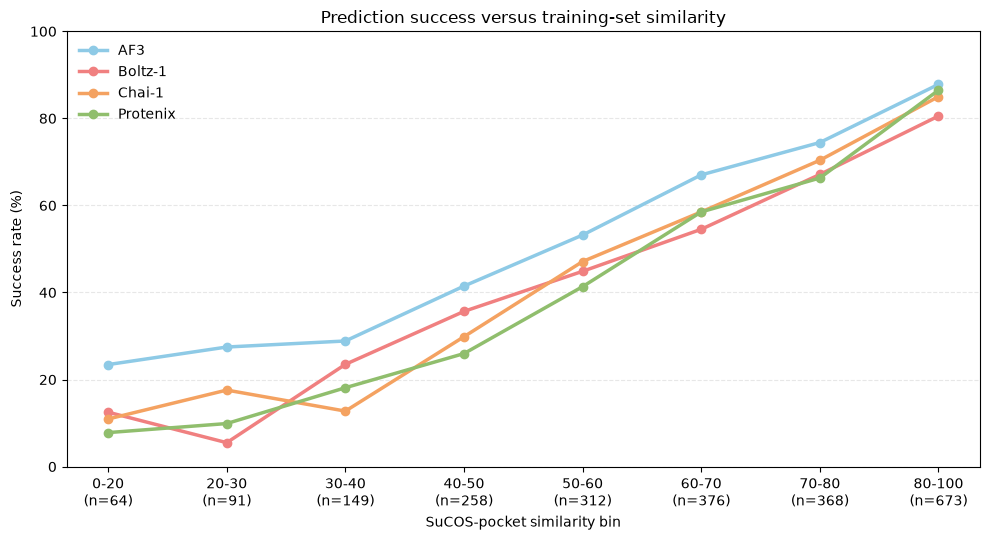

Plotted data points: 2291
Unbinned data points: 1
Saved figure: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\analysis_outputs\success_vs_training_set_similarity.png


In [12]:
# Plot and save the reproduced success-versus-similarity figure.
METHOD_COLORS = {
    "AF3": "#8ecae6",
    "Boltz-1": "#f08080",
    "Chai-1": "#f4a261",
    "Protenix": "#90be6d",
}

x_positions = np.arange(len(figure_summary))
fig, ax = plt.subplots(figsize=(10, 5.5))

for method_name in success_columns:
    ax.plot(
        x_positions,
        figure_summary[method_name],
        marker="o",
        linewidth=2.5,
        markersize=6,
        color=METHOD_COLORS[method_name],
        label=method_name
    )

ax.set_xticks(x_positions)
ax.set_xticklabels([
    f"{similarity_bin}\n(n={sample_size})"
    for similarity_bin, sample_size in zip(
        figure_summary["similarity_bin"],
        figure_summary["n"]
    )
])
ax.set(
    xlabel="SuCOS-pocket similarity bin",
    ylabel="Success rate (%)",
    title="Prediction success versus training-set similarity"
)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()

figure_path = (
    ANALYSIS_OUTPUT_DIR / "success_vs_training_set_similarity.png"
)
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Plotted data points:", int(figure_summary["n"].sum()))
print("Unbinned data points:", len(unbinned_figure_data))
print("Saved figure:", figure_path)


## Section 3

### Objective

This section investigates how the query-training pairs stored in the Runs N' Poses similarity parquet were generated.

The similarity parquet does not contain the same number of training-system pairs for every query. Some query systems are associated with only one or two training systems, whereas others are associated with several thousand.

According to the Runs N' Poses Methods, the authors first performed a Foldseek search against the PDB. Similarity measurements were then calculated only for query-target pairs for which at least one protein chain had a Foldseek alignment.

The PDB entries retained by Foldseek can subsequently expand into multiple PLINDER systems because one PDB biological assembly may contain several protein-ligand systems.

This section evaluates two related hypotheses:

1. **Foldseek prefilter hypothesis**  
   The variable number of training pairs per query is partly explained by the Foldseek structural-search step. Queries with common protein folds are expected to recover many PDB entries, whereas queries with uncommon folds are expected to recover fewer entries.

2. **PLINDER system-construction hypothesis**  
   The system identifiers stored in the Runs N' Poses similarity parquet are expected to correspond to the system definitions generated by PLINDER from the associated PDB structures.

### Validation strategy

The validation is divided into two parts.

#### Part A: Foldseek candidate recovery

A highly connected query system is selected as a case study. The target PDB entries associated with this query in the similarity parquet are treated as expected Foldseek-positive structures.

The validation database contains:

- all PDB entries paired with the selected query in the similarity parquet; and
- 50 randomly selected PDB entries that are not paired with the query.

Foldseek is run using the query structure against this combined database. The recovered PDB entries are then compared with the expected positive and random-control sets.

A complete recovery of the expected positives, together with the absence of random-control hits, supports the use of Foldseek as a structural prefilter for this query. However, this single-query experiment should be interpreted as a consistency check rather than proof of the complete Runs N' Poses pipeline.

#### Part B: PLINDER system reconstruction

For one selected PDB entry, PLINDER is used to reconstruct the system definitions directly from its mmCIF file.

The generated PLINDER system IDs are compared with the system IDs involving the same PDB entry in the Runs N' Poses similarity parquet.

An exact match supports the hypothesis that Runs N' Poses used PLINDER system definitions when converting Foldseek-selected PDB entries into protein-ligand systems.

### Computational environments

The Foldseek validation can be prepared in the main project environment.

The PLINDER reconstruction must be executed using the dedicated `plinder` Conda environment. PLINDER itself does not conceptually require a separate environment, but its compiled dependencies, particularly OpenStructure, Foldseek, MMseqs2, RDKit, NumPy, and related scientific packages, conflicted with the versions used in the main project environment.

The dedicated environment prevents PLINDER installation from modifying or breaking the dependencies used by the rest of the analysis.

Package installation commands are not included in the notebook. Before running the PLINDER subsection, the Jupyter kernel must be changed to the dedicated `plinder` environment.

### Part A — Foldseek system validation

In [13]:
# Count the number of query-training system pairs stored for each query.

# A row in the similarity parquet represents a pair of PLINDER systems, not necessarily a unique pair of PDB entries. 
# One target PDB can generate multiple target systems and therefore multiple parquet rows.
hits_per_query = (
    sim.groupby("query_system")
    .size()
    .sort_values(ascending=False)
)


# Display the overall distribution of training-pair counts.
display(
    hits_per_query.describe()
)


# Display the most highly connected query systems.
display(
    hits_per_query.head(20)
)


# Display the least connected query systems.
display(
    hits_per_query.sort_values().head(20)
)

count     2599.000000
mean      1486.238553
std       1820.119526
min          2.000000
25%        165.000000
50%        654.000000
75%       2708.500000
max      15475.000000
dtype: float64

query_system
8fm5__1__1.A__1.K                  15475
8fm0__1__1.A__1.K                  15475
8flz__1__1.A__1.K                  15475
8fm2__1__1.A__1.K                  15475
8fm7__1__1.A__1.K                  15473
8fm4__1__1.A__1.K                  15473
8gdk__1__1.A__1.O                  15472
8fm8__1__1.A__1.K                  15472
8fm3__1__1.A__1.K                  15470
8fly__1__1.A__1.K                  15470
7tjo__1__1.A__1.E                  15469
8gcz__1__1.A__1.N                  15466
8c1f__1__1.A__1.B_1.C_1.D_1.J       9758
8gb4__1__1.A__1.E_1.F_1.G           9036
7ltx__1__1.A__1.E_1.F_1.G           8925
7v0h__1__1.B__1.N_1.P               7852
7yb2__1__1.C__1.L_1.M               7743
8bsu__1__1.A_1.D__1.I_1.OA_1.SA     7196
7eji__1__1.D__1.V_1.W               7125
8fdk__1__1.B__1.F_1.H               7018
dtype: int64

query_system
8rcw__1__1.A__1.C                2
8ki5__1__1.A__1.B                2
8k2m__1__1.A__1.B                2
8k2k__1__1.A__1.B                2
8ol4__1__1.B_1.C__1.P            3
8f5v__1__1.A_1.B__1.C_1.D        3
7tem__1__1.A__1.C_1.G            3
7ef7__1__1.A__1.B_1.C            4
7vwt__1__1.B__1.H                4
7wux__1__1.A_1.D__1.J            4
7sez__1__1.A__1.B                4
7t9r__1__1.A__1.F                4
7p97__1__1.A__1.C_1.D_1.E        5
8jbi__1__2.C_2.D__2.I_2.M        5
7f14__1__1.B__1.D                6
7w3s__1__1.B_1.D__1.F            6
8tl8__1__1.A__1.C                6
8twj__1__1.A__1.B_1.C_1.D_1.E    7
8oru__1__1.A_1.B__1.M            7
8dml__1__1.B__1.J                7
dtype: int64

In [14]:
# Select one of the most conected queries for doing the Foldseek validation.
FOLDSEEK_QUERY_SYSTEM = "8flz__1__1.A__1.K"

# Extract all similarity-parquet rows associated with the selected query.
foldseek_query_pairs = sim.loc[
    sim["query_system"].eq(FOLDSEEK_QUERY_SYSTEM)
].copy()


# Extract the PDB identifier from every target PLINDER system.

# A single PDB entry may contain multiple PLINDER systems. Therefore, the number of query-training system pairs can be much larger than
# the number of unique target PDB entries.
foldseek_query_pairs["target_pdb_id"] = (
    foldseek_query_pairs["target_system"]
    .str.split("__")
    .str[0]
    .str.lower()
)


print(
    "Selected query system:",
    FOLDSEEK_QUERY_SYSTEM,
)

print(
    "Query-training system pairs:",
    len(foldseek_query_pairs),
)

print(
    "Unique target PDB entries:",
    foldseek_query_pairs["target_pdb_id"].nunique(),
)


# Describe the protein sequence identities among the retained pairs.
display(
    foldseek_query_pairs["protein_fident_max"].describe()
)

Selected query system: 8flz__1__1.A__1.K
Query-training system pairs: 15475
Unique target PDB entries: 531


count    15475.000000
mean        62.070436
std         10.429869
min         23.000000
25%         58.000000
50%         59.000000
75%         64.000000
max        100.000000
Name: protein_fident_max, dtype: float64

In [15]:
# Treat the target PDB entries already paired with the selected query in the Runs N' Poses parquet as the expected Foldseek-positive set.
expected_positive_pdbs = set(
    foldseek_query_pairs["target_pdb_id"]
    .dropna()
    .unique()
)


# Extract every target PDB represented in the similarity parquet.
all_target_pdbs = set(
    sim["target_system"]
    .dropna()
    .str.split("__")
    .str[0]
    .str.lower()
    .unique()
)


# Construct the negative-control pool from PDB entries that are not paired with the selected query.
negative_control_pool = sorted(
    all_target_pdbs - expected_positive_pdbs
)

# Use a fixed seed so the same random controls are selected every time.
RANDOM_SEED = 42
NUMBER_OF_RANDOM_CONTROLS = 50


# Extract the four-character PDB identifier from the full PLINDER query-system
# identifier. For example, "8flz__1__1.A__1.K" becomes "8flz".
foldseek_query_pdb = (
    FOLDSEEK_QUERY_SYSTEM
    .split("__")[0]
    .lower()
)


# Standardise all PDB identifiers as lowercase strings.
expected_positive_pdbs = {
    str(pdb_id).lower()
    for pdb_id in expected_positive_pdbs
}

negative_control_pool = {
    str(pdb_id).lower()
    for pdb_id in negative_control_pool
}


# Remove all PDB entries associated with the 8FLZ query from the candidate
# control pool. The query PDB itself is also explicitly excluded.
eligible_negative_control_pdbs = sorted(
    negative_control_pool
    - expected_positive_pdbs
    - {foldseek_query_pdb}
)


# Confirm that enough eligible PDB entries remain for sampling.
if len(eligible_negative_control_pdbs) < NUMBER_OF_RANDOM_CONTROLS:
    raise ValueError(
        "There are not enough eligible negative-control PDB entries. "
        f"Required: {NUMBER_OF_RANDOM_CONTROLS}; "
        f"available: {len(eligible_negative_control_pdbs)}."
    )


# Select 50 unique control PDB entries reproducibly and without replacement.
random_generator = np.random.default_rng(
    RANDOM_SEED
)

random_control_pdbs = set(
    random_generator.choice(
        eligible_negative_control_pdbs,
        size=NUMBER_OF_RANDOM_CONTROLS,
        replace=False,
    )
)


# Verify that the positive and random-control PDB sets are completely disjoint.
overlapping_pdbs = (
    expected_positive_pdbs
    & random_control_pdbs
)

assert not overlapping_pdbs, (
    "The positive and random-control PDB sets overlap: "
    + ", ".join(sorted(overlapping_pdbs))
)


print("Query PDB entry:", foldseek_query_pdb)
print("Expected-positive PDB entries:", len(expected_positive_pdbs))
print(
    "Eligible negative-control PDB entries:",
    len(eligible_negative_control_pdbs),
)
print(
    "Selected random-control PDB entries:",
    len(random_control_pdbs),
)
print(
    "Overlap between positive and control PDB entries:",
    len(overlapping_pdbs),
)

Query PDB entry: 8flz
Expected-positive PDB entries: 531
Eligible negative-control PDB entries: 70363
Selected random-control PDB entries: 50
Overlap between positive and control PDB entries: 0


In [16]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import requests

In [17]:
# The Foldseek working directories are derived from BASE_PATH. 

# Define the directory used for the Foldseek validation.
FOLDSEEK_VALIDATION_DIR = (
    BASE_PATH
    / "foldseek_validation"
)

# Store the query structure separately from the structures used to build the
# Foldseek search database.
FOLDSEEK_QUERY_DIR = (
    FOLDSEEK_VALIDATION_DIR
    / "query"
)

FOLDSEEK_DATABASE_DIR = (
    FOLDSEEK_VALIDATION_DIR
    / "db_cifs"
)

# Create all directories if they do not already exist.
FOLDSEEK_QUERY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FOLDSEEK_DATABASE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Extract the four-character PDB identifier from the full PLINDER system ID.
foldseek_query_pdb = (
    FOLDSEEK_QUERY_SYSTEM
    .split("__")[0]
    .lower()
)

# Build the validation database from:
# 1. the PDB entries paired with the query system in Runs N' Poses; and
# 2. the randomly selected negative-control PDB entries.
validation_database_pdbs = sorted(
    set(expected_positive_pdbs)
    | set(random_control_pdbs)
)

In [18]:
# Download the structures required for the Foldseek validation

# The download is:
# - resumable: existing non-empty files are not downloaded again;
# - parallelised: several structures are downloaded simultaneously;
# - fault-tolerant: failed downloads are retried;
# - validated: the cell stops if any required structure is still missing.

def download_pdb_cif(
    pdb_id,
    destination_directory,
    maximum_attempts=3,
):
    """
    Download one PDB mmCIF structure from the RCSB archive.

    Existing non-empty files are preserved, which makes the download resumable.
    Each incomplete download is first written to a temporary '.part' file and
    is renamed only after the complete response has been received.

    Parameters
    ----------
    pdb_id : str
        Four-character PDB identifier.

    destination_directory : pathlib.Path
        Directory in which the mmCIF file will be stored.

    maximum_attempts : int, default=3
        Maximum number of download attempts before reporting a failure.

    Returns
    -------
    dict
        Download status, PDB identifier, local path, and error information.
    """

    pdb_id = str(pdb_id).lower()

    output_path = (
        destination_directory
        / f"{pdb_id}.cif"
    )

    temporary_path = (
        destination_directory
        / f"{pdb_id}.cif.part"
    )

    # Do not download the structure again if a non-empty file already exists.
    if output_path.exists() and output_path.stat().st_size > 0:
        return {
            "pdb_id": pdb_id,
            "status": "already present",
            "path": str(output_path),
            "error": None,
        }

    download_url = (
        "https://files.rcsb.org/download/"
        f"{pdb_id.upper()}.cif"
    )

    last_error = None

    for attempt_number in range(1, maximum_attempts + 1):

        try:
            # Remove an incomplete file left by a previously interrupted run.
            if temporary_path.exists():
                temporary_path.unlink()

            with requests.get(
                download_url,
                stream=True,
                timeout=(10, 90),
                headers={
                    "User-Agent":
                    "Runs-N-Poses-Foldseek-validation/1.0"
                },
            ) as response:

                response.raise_for_status()

                with temporary_path.open("wb") as output_file:

                    for chunk in response.iter_content(
                        chunk_size=1024 * 1024
                    ):
                        if chunk:
                            output_file.write(chunk)

            # Reject an empty response before accepting the downloaded file.
            if temporary_path.stat().st_size == 0:
                raise ValueError(
                    f"The downloaded file for {pdb_id} is empty."
                )

            # Rename the completed temporary file atomically.
            temporary_path.replace(output_path)

            return {
                "pdb_id": pdb_id,
                "status": "downloaded",
                "path": str(output_path),
                "error": None,
            }

        except Exception as error:
            last_error = str(error)

            if temporary_path.exists():
                temporary_path.unlink()

            # Wait briefly before retrying the request.
            if attempt_number < maximum_attempts:
                time.sleep(2 ** attempt_number)

    return {
        "pdb_id": pdb_id,
        "status": "failed",
        "path": str(output_path),
        "error": last_error,
    }


# Download the query structure before building the validation database.
query_download_result = download_pdb_cif(
    pdb_id=foldseek_query_pdb,
    destination_directory=FOLDSEEK_QUERY_DIR,
)

if query_download_result["status"] == "failed":
    raise RuntimeError(
        "The Foldseek query structure could not be downloaded: "
        f"{query_download_result['error']}"
    )


# Use a moderate number of simultaneous requests. 
# This is much faster than downloading the structures sequentially without overloading the RCSB server.
MAXIMUM_PARALLEL_DOWNLOADS = 6

download_results = []

with ThreadPoolExecutor(
    max_workers=MAXIMUM_PARALLEL_DOWNLOADS
) as executor:

    download_tasks = {
        executor.submit(
            download_pdb_cif,
            pdb_id,
            FOLDSEEK_DATABASE_DIR,
        ): pdb_id
        for pdb_id in validation_database_pdbs
    }

    total_downloads = len(download_tasks)

    for completed_count, completed_task in enumerate(
        as_completed(download_tasks),
        start=1,
    ):
        download_results.append(
            completed_task.result()
        )

        # Print occasional progress updates without producing hundreds of lines.
        if (
            completed_count % 25 == 0
            or completed_count == total_downloads
        ):
            print(
                f"Processed {completed_count}/{total_downloads} "
                "validation structures."
            )


# Store a download manifest so the result can be audited later.
foldseek_download_manifest = (
    pd.DataFrame(download_results)
    .sort_values("pdb_id")
    .reset_index(drop=True)
)

foldseek_download_manifest_path = (
    FOLDSEEK_VALIDATION_DIR
    / "download_manifest.csv"
)

foldseek_download_manifest.to_csv(
    foldseek_download_manifest_path,
    index=False,
)


# Verify that every expected database structure exists and is non-empty.
missing_or_empty_pdbs = [
    pdb_id
    for pdb_id in validation_database_pdbs
    if not (
        FOLDSEEK_DATABASE_DIR / f"{pdb_id}.cif"
    ).exists()
    or (
        FOLDSEEK_DATABASE_DIR / f"{pdb_id}.cif"
    ).stat().st_size == 0
]

print()
print("Query structure:", foldseek_query_pdb)
print(
    "Expected validation-database structures:",
    len(validation_database_pdbs),
)
print(
    "Downloaded in this run:",
    (
        foldseek_download_manifest["status"]
        == "downloaded"
    ).sum(),
)
print(
    "Already present:",
    (
        foldseek_download_manifest["status"]
        == "already present"
    ).sum(),
)
print(
    "Failed or missing:",
    len(missing_or_empty_pdbs),
)
print(
    "Download manifest:",
    foldseek_download_manifest_path,
)


# Do not continue to Foldseek with an incomplete validation database.
if missing_or_empty_pdbs:
    raise RuntimeError(
        "The Foldseek validation database is incomplete. "
        "Run this cell again to retry the missing structures. "
        "Missing PDB IDs: "
        + ", ".join(missing_or_empty_pdbs[:20])
    )

print(
    "\nAll required structures are available. "
    "The Foldseek search can now be executed."
)

Processed 25/581 validation structures.
Processed 50/581 validation structures.
Processed 75/581 validation structures.
Processed 100/581 validation structures.
Processed 125/581 validation structures.
Processed 150/581 validation structures.
Processed 175/581 validation structures.
Processed 200/581 validation structures.
Processed 225/581 validation structures.
Processed 250/581 validation structures.
Processed 275/581 validation structures.
Processed 300/581 validation structures.
Processed 325/581 validation structures.
Processed 350/581 validation structures.
Processed 375/581 validation structures.
Processed 400/581 validation structures.
Processed 425/581 validation structures.
Processed 450/581 validation structures.
Processed 475/581 validation structures.
Processed 500/581 validation structures.
Processed 525/581 validation structures.
Processed 550/581 validation structures.
Processed 575/581 validation structures.
Processed 581/581 validation structures.

Query structure: 8

### Running Foldseek

Foldseek is executed from a Bash terminal using the query and validation-database mmCIF files prepared in the previous cells.

The validation database contains exactly 581 PDB structures:

- 531 expected-positive PDB entries associated with the selected `8flz` query in the Runs N' Poses similarity parquet; and
- 50 randomly selected control PDB entries that are not among the 531 expected positives.

Before constructing the database, the notebook verifies that the expected-positive and random-control sets do not overlap.

#### 1. Define the validation-directory path

The Bash variable `FOLDSEEK_DIR` must point to the same directory represented by `FOLDSEEK_VALIDATION_DIR` in Python.

The number of target mmCIF files can be verified before constructing the Foldseek database:

```bash
find "$FOLDSEEK_DIR/db_cifs" \
    -maxdepth 1 \
    -type f \
    -name "*.cif" \
    | wc -l
```

The command should return:

```text
581
```

#### 2. Create a new Foldseek target database

The following command converts the 581 mmCIF structures stored in `db_cifs` into a new Foldseek database:

```bash
foldseek createdb \
    "$FOLDSEEK_DIR/db_cifs" \
    "$FOLDSEEK_DIR/db_final"
```

Here:

- `"$FOLDSEEK_DIR/db_cifs"` is the directory containing the 581 target mmCIF files. 
- `"$FOLDSEEK_DIR/db_final"` is the output prefix of the Foldseek database.

Foldseek creates several database files using the `db_final` prefix. Therefore, `db_final` is a database-file prefix rather than a directory containing the original mmCIF structures.

A new database prefix is used to ensure that the database is constructed from the current set of 531 expected-positive and 50 random-control structures, without reusing files from a previous validation run.

#### 3. Search the 8FLZ structure against the validation database

```bash
foldseek easy-search \
    "$FOLDSEEK_DIR/query/8flz.cif" \
    "$FOLDSEEK_DIR/db_final" \
    "$FOLDSEEK_DIR/results_final.m8" \
    "$FOLDSEEK_DIR/tmp_final" \
    -e 0.001 \
    --max-seqs 100000 \
    --format-output "query,target,evalue,bits,fident,alntmscore,qtmscore,ttmscore"
```

The command arguments are:

1. `query/8flz.cif`: the complete 8FLZ query structure;
2. `db_final`: the Foldseek database constructed from the 581 validation structures;
3. `results_final.m8`: the tab-separated output file;
4. `tmp_final`: the temporary directory used internally by Foldseek;
5. `-e 0.001`: the maximum E-value accepted for a reported alignment;
6. `--max-seqs 100000`: the maximum number of target sequences passed from the prefilter to the alignment stage; and
7. `--format-output`: the columns written to the result file.

An explicit E-value threshold is required because Foldseek version `10.941cd33` uses a default threshold of `10`. That default reports very weak alignments, including matches with low bit scores and TM-scores close to zero. Setting `-e 0.001` excludes these non-significant alignments and prevents them from being interpreted as recovered control structures.

The output columns are:

- `query`: Foldseek identifier of the query chain;
- `target`: Foldseek identifier of the target chain;
- `evalue`: statistical significance of the alignment;
- `bits`: alignment bit score;
- `fident`: fraction of identical aligned residues;
- `alntmscore`: TM-score calculated over the aligned region;
- `qtmscore`: TM-score normalised by the query length; and
- `ttmscore`: TM-score normalised by the target length.

#### 4. Load the Foldseek results in Python

The resulting file is subsequently loaded in Python from:

```python
FOLDSEEK_RESULTS_PATH = (
    FOLDSEEK_VALIDATION_DIR
    / "results_final.m8"
)
```

The Python analysis extracts the four-character PDB identifier from every Foldseek target-chain identifier and determines whether each expected-positive or random-control PDB entry produced at least one significant alignment.

#### Validation objective

This experiment tests whether an independent Foldseek search can recover the PDB entries associated with the `8flz` query in the Runs N' Poses similarity parquet while excluding PDB entries selected as negative controls.

Using the database and E-value threshold described above, Foldseek recovered all 531 expected-positive PDB entries and excluded all 50 random-control PDB entries:

- positive recall: `1.00`;
- missing expected-positive PDB entries: `0`;
- random controls with a significant hit: `0`; and
- control false-positive rate: `0.00`.

In [29]:
# Define the path of the result file generated by the Foldseek search.
# This file is created by the Bash command and is not downloaded from the PDB.
FOLDSEEK_RESULTS_PATH = (
    FOLDSEEK_VALIDATION_DIR
    / "results_final.m8"
)

# Confirm that the Foldseek result file exists before attempting to load it.
if not FOLDSEEK_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "The Foldseek result file was not found at:\n"
        f"{FOLDSEEK_RESULTS_PATH}\n\n"
        "The structure downloads do not need to be repeated. "
        "Run the Foldseek Bash command to generate this result file."
    )

print("Foldseek result file:", FOLDSEEK_RESULTS_PATH)

# Define the columns written by the Foldseek command.
FOLDSEEK_RESULT_COLUMNS = [
    "query",
    "target",
    "evalue",
    "bits",
    "fident",
    "alntmscore",
    "qtmscore",
    "ttmscore",
]


# Read the previously generated Foldseek result file.
foldseek_results = pd.read_csv(
    FOLDSEEK_RESULTS_PATH,
    sep="\t",
    header=None,
    names=FOLDSEEK_RESULT_COLUMNS,
)


# Extract the target PDB ID from Foldseek chain identifiers such as 8flz_A.
foldseek_results["target_pdb_id"] = (
    foldseek_results["target"]
    .str.split("_")
    .str[0]
    .str.lower()
)


# Label each result according to the expected validation set.
foldseek_results["expected_set"] = np.select(
    [
        foldseek_results["target_pdb_id"].isin(
            expected_positive_pdbs
        ),
        foldseek_results["target_pdb_id"].isin(
            random_control_pdbs
        ),
    ],
    [
        "expected_positive",
        "random_control",
    ],
    default="outside_validation_database",
)


display(
    foldseek_results.head(10)
)

Foldseek result file: C:\Users\emitr\OneDrive\Documentos\University of Southampton\Final Project\Dataset\foldseek_validation\results_final.m8


,query,target,evalue,bits,fident,alntmscore,qtmscore,ttmscore,target_pdb_id,expected_set
0,8flz_D,8flz_A,2.006000e-75,3214,1.0,1.003,1.0000,1.0000,8flz,expected_positive
1,8flz_D,8flz_D,2.006000e-75,3214,1.0,1.003,1.0000,1.0000,8flz,expected_positive
2,8flz_D,8flz_B,2.006000e-75,3214,1.0,1.003,1.0000,1.0000,8flz,expected_positive
3,8flz_D,8flz_C,2.006000e-75,3214,1.0,1.003,1.0000,1.0000,8flz,expected_positive
4,8flz_D,8fm4_B,5.767000e-72,3067,1.0,1.002,0.9995,0.9995,8fm4,expected_positive
5,8flz_D,8fm4_D,5.767000e-72,3067,1.0,1.002,0.9995,0.9995,8fm4,expected_positive
6,8flz_D,8fm4_A,5.767000e-72,3067,1.0,1.002,0.9995,0.9995,8fm4,expected_positive
7,8flz_D,8fm4_C,5.767000e-72,3067,1.0,1.002,0.9995,0.9995,8fm4,expected_positive
8,8flz_D,8fly_A,6.437000e-72,3064,1.0,1.002,0.9995,0.9995,8fly,expected_positive
9,8flz_D,8fly_B,6.437000e-72,3064,1.0,1.002,0.9995,0.9995,8fly,expected_positive


In [30]:
# Retain the highest-bit-score Foldseek alignment for every target PDB.

# Foldseek searches protein chains, so one PDB may produce several chain alignments. Collapsing by target_pdb_id prevents a multi-chain PDB from being counted several times in the validation.
best_foldseek_hit_per_pdb = (
    foldseek_results
    .sort_values(
        "bits",
        ascending=False,
    )
    .drop_duplicates(
        subset=["target_pdb_id"],
        keep="first",
    )
    .reset_index(drop=True)
)


# Extract the PDB entries recovered by Foldseek.
recovered_pdbs = set(
    best_foldseek_hit_per_pdb["target_pdb_id"]
)


recovered_positive_pdbs = (
    recovered_pdbs
    & expected_positive_pdbs
)

recovered_random_controls = (
    recovered_pdbs
    & random_control_pdbs
)

missing_positive_pdbs = (
    expected_positive_pdbs
    - recovered_pdbs
)


# Calculate recovery statistics.
positive_recall = (
    len(recovered_positive_pdbs)
    / len(expected_positive_pdbs)
)

control_false_positive_rate = (
    len(recovered_random_controls)
    / len(random_control_pdbs)
)


foldseek_validation_summary = pd.Series({
    "expected_positive_pdbs": len(expected_positive_pdbs),
    "recovered_positive_pdbs": len(recovered_positive_pdbs),
    "missing_positive_pdbs": len(missing_positive_pdbs),
    "random_control_pdbs": len(random_control_pdbs),
    "recovered_random_controls": len(recovered_random_controls),
    "positive_recall": positive_recall,
    "control_false_positive_rate": control_false_positive_rate,
})


display(
    foldseek_validation_summary.to_frame("value")
)


print(
    "All expected positives recovered:",
    not missing_positive_pdbs,
)

print(
    "All random controls excluded:",
    not recovered_random_controls,
)

,value
expected_positive_pdbs,531.0
recovered_positive_pdbs,531.0
missing_positive_pdbs,0.0
random_control_pdbs,50.0
recovered_random_controls,0.0
positive_recall,1.0
control_false_positive_rate,0.0


All expected positives recovered: True
All random controls excluded: True


### Part B — PLINDER system validation

In [6]:
# Select one PDB entry for the PLINDER reconstruction experiment.

# The same PDB used in the Foldseek case study is retained so the two validation stages form one continuous example.
PLINDER_TEST_PDB_ID = "8flz"


# Collect every Runs N' Poses system ID associated with this PDB.
all_runsnposes_system_ids = pd.concat(
    [
        sim["query_system"],
        sim["target_system"],
    ],
    ignore_index=True,
).dropna().astype(str)


expected_runsnposes_systems = sorted(
    system_id
    for system_id in all_runsnposes_system_ids.unique()
    if system_id.startswith(
        f"{PLINDER_TEST_PDB_ID}__"
    )
)


# Save the expected IDs because the PLINDER subsection is executed in a different Conda environment and Jupyter kernel.
EXPECTED_SYSTEM_IDS_PATH = (
    ANALYSIS_OUTPUT_DIR
    / f"{PLINDER_TEST_PDB_ID}_runsnposes_system_ids.txt"
)

pd.Series(
    expected_runsnposes_systems
).to_csv(
    EXPECTED_SYSTEM_IDS_PATH,
    index=False,
    header=False,
)


print(
    "Expected Runs N' Poses systems:",
    len(expected_runsnposes_systems),
)

print(
    "Saved system IDs:",
    EXPECTED_SYSTEM_IDS_PATH,
)

Expected Runs N' Poses systems: 30
Saved system IDs: /local/scratch/et3n25/Datasets/runs_n_poses/analysis_outputs/8flz_runsnposes_system_ids.txt


### Switching to the PLINDER environment

The following cells must be executed using the dedicated `plinder` Conda environment.

Before continuing:

1. select the `plinder` kernel in Jupyter;
2. rerun the global `BASE_PATH` configuration cell; and
3. continue from the PLINDER import cell below.

The environment is isolated because PLINDER depends on compiled scientific packages, including OpenStructure, whose required versions conflicted with the main analysis environment.

In [13]:
# Configure the PLINDER release before importing the reconstruction tools.
import os
from pathlib import Path
import urllib.request
import pandas as pd

os.environ["PLINDER_RELEASE"] = "2024-04"
os.environ["PLINDER_ITERATION"] = "v1"

from plinder.data.utils.annotations.aggregate_annotations import Entry
import plinder.data.pipeline.io as pio
import plinder.data.utils.annotations.aggregate_annotations as aa

# Disable external affinity-data downloads
pio.download_affinity_data = lambda *args, **kwargs: None
pio.download_bindingdb_affinity_data = lambda *args, **kwargs: None

# Disable optional annotations not required to generate system IDs
aa.Entry.add_ecod = lambda self, *args, **kwargs: None
aa.Entry.add_panther = lambda self, *args, **kwargs: None
aa.Entry.add_kinase = lambda self, *args, **kwargs: None

In [8]:
# Recreate the derived paths after switching Jupyter kernels.
ANALYSIS_OUTPUT_DIR = BASE_PATH / "analysis_outputs"

PLINDER_VALIDATION_DIR = (
    BASE_PATH / "validation" / "plinder"
)

PLINDER_CIF_DIR = (
    PLINDER_VALIDATION_DIR / "cifs"
)

PLINDER_GENERATED_DIR = (
    PLINDER_VALIDATION_DIR / "generated"
)

PLINDER_CIF_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PLINDER_GENERATED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PLINDER_TEST_PDB_ID = "8flz"

EXPECTED_SYSTEM_IDS_PATH = (
    ANALYSIS_OUTPUT_DIR
    / f"{PLINDER_TEST_PDB_ID}_runsnposes_system_ids.txt"
)

In [11]:
# Load the Runs N' Poses system IDs saved before changing kernels.
expected_runsnposes_systems = (
    pd.read_csv(
        EXPECTED_SYSTEM_IDS_PATH,
        header=None,
        names=["system_id"],
    )["system_id"]
    .dropna()
    .astype(str)
    .sort_values()
    .tolist()
)


# Download the compressed mmCIF file used for PLINDER reconstruction.
plinder_cif_path = (
    PLINDER_CIF_DIR
    / f"{PLINDER_TEST_PDB_ID}.cif.gz"
)

if not plinder_cif_path.exists():
    urllib.request.urlretrieve(
        (
            "https://files.rcsb.org/download/"
            f"{PLINDER_TEST_PDB_ID.upper()}.cif.gz"
        ),
        plinder_cif_path,
    )


print(
    "Expected Runs N' Poses systems:",
    len(expected_runsnposes_systems),
)

print(
    "PLINDER input structure:",
    plinder_cif_path,
)

Expected Runs N' Poses systems: 30
PLINDER input structure: /local/scratch/et3n25/Datasets/runs_n_poses/validation/plinder/cifs/8flz.cif.gz


In [14]:
# Reconstruct the PLINDER systems directly from the selected mmCIF file.

# PoseBusters and system-file export are disabled because this validation only requires the generated system identifiers.
plinder_entry = Entry.from_cif_file(
    cif_file=plinder_cif_path,
    save_folder=(
        PLINDER_GENERATED_DIR
        / PLINDER_TEST_PDB_ID
    ),
    skip_save_systems=True,
    skip_posebusters=True,
)


generated_plinder_systems = sorted(
    plinder_entry.systems.keys()
)


print(
    "Generated PLINDER systems:",
    len(generated_plinder_systems),
)

display(
    generated_plinder_systems[:30]
)

2026-08-06 09:09:37,512 | plinder.data.pipeline.io:180 | INFO : download_components_cif: https://files.wwpdb.org/pub/pdb/data/monomers/components.cif.gz
2026-08-06 09:09:44,273 | plinder.data.pipeline.io:190 | INFO : download_components_cif: transforming /local/scratch/et3n25/Datasets/runs_n_poses/validation/plinder/dbs/components/components.cif
2026-08-06 09:09:48,498 | plinder.data.pipeline.io:64 | INFO : download_cofactors: https://www.ebi.ac.uk/pdbe/api/pdb/compound/cofactors
2026-08-06 09:09:49,608 | plinder.data.pipeline.io:341 | INFO : download_kinase_data: data_dir=/local/scratch/et3n25/Datasets/runs_n_poses/validation/plinder
2026-08-06 09:09:49,609 | plinder.data.pipeline.io:344 | INFO : download_kinase_data: https://klifs.net/api//kinase_information
2026-08-06 09:09:50,108 | plinder.data.pipeline.io:351 | INFO : download_kinase_data: https://klifs.net/api//ligands_list
2026-08-06 09:09:50,426 | plinder.data.pipeline.io:360 | INFO : download_kinase_data: https://klifs.net/api

Generated PLINDER systems: 30


['8flz__1__1.A__1.E',
 '8flz__1__1.A__1.F',
 '8flz__1__1.A__1.G',
 '8flz__1__1.A__1.H',
 '8flz__1__1.A__1.I',
 '8flz__1__1.A__1.J',
 '8flz__1__1.A__1.K',
 '8flz__1__1.A__1.L',
 '8flz__2__1.B__1.M',
 '8flz__2__1.B__1.N',
 '8flz__2__1.B__1.O',
 '8flz__2__1.B__1.P',
 '8flz__2__1.B__1.Q',
 '8flz__2__1.B__1.R',
 '8flz__2__1.B__1.S',
 '8flz__3__1.C__1.T',
 '8flz__3__1.C__1.U',
 '8flz__3__1.C__1.V',
 '8flz__3__1.C__1.W',
 '8flz__3__1.C__1.X',
 '8flz__3__1.C__1.Y',
 '8flz__3__1.C__1.Z',
 '8flz__4__1.D__1.AA',
 '8flz__4__1.D__1.BA',
 '8flz__4__1.D__1.CA',
 '8flz__4__1.D__1.DA',
 '8flz__4__1.D__1.EA',
 '8flz__4__1.D__1.FA',
 '8flz__4__1.D__1.GA',
 '8flz__4__1.D__1.HA']

In [15]:
# Compare the PLINDER-generated identifiers with the identifiers stored in the Runs N' Poses similarity parquet.
plinder_system_set = set(
    generated_plinder_systems
)

runsnposes_system_set = set(
    expected_runsnposes_systems
)


systems_in_both = (
    plinder_system_set
    & runsnposes_system_set
)

systems_only_in_plinder = (
    plinder_system_set
    - runsnposes_system_set
)

systems_only_in_runsnposes = (
    runsnposes_system_set
    - plinder_system_set
)


plinder_validation_summary = pd.Series({
    "generated_plinder_systems": len(plinder_system_set),
    "runsnposes_systems": len(runsnposes_system_set),
    "systems_in_both": len(systems_in_both),
    "systems_only_in_plinder": len(systems_only_in_plinder),
    "systems_only_in_runsnposes": len(systems_only_in_runsnposes),
    "perfect_match": (
        plinder_system_set
        == runsnposes_system_set
    ),
})


display(
    plinder_validation_summary.to_frame("value")
)


print("\nSystems only in PLINDER:")

display(
    sorted(systems_only_in_plinder)
)


print("\nSystems only in Runs N' Poses:")

display(
    sorted(systems_only_in_runsnposes)
)

,value
generated_plinder_systems,30
runsnposes_systems,30
systems_in_both,30
systems_only_in_plinder,0
systems_only_in_runsnposes,0
perfect_match,True



Systems only in PLINDER:


[]


Systems only in Runs N' Poses:


[]

### PLINDER reconstruction result

The system identifiers generated directly from the selected mmCIF file are compared with the Runs N' Poses system identifiers associated with the same PDB entry.

A perfect set match supports the hypothesis that Runs N' Poses used PLINDER to convert PDB entries selected by the Foldseek search into protein-ligand systems.

A mismatch would not necessarily disprove the use of PLINDER. Differences could also arise from:

- a different PLINDER release or iteration;
- changes in PLINDER system-definition rules;
- obsolete or updated PDB biological assemblies;
- missing auxiliary annotations;
- Runs N' Poses-specific filtering; or
- differences in ligand and polymer classification.

The comparison must therefore record the exact PLINDER release, iteration, package version, and input mmCIF file used for reconstruction.